In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error as mse
import cuqi
from cuqi.testproblem import Deconvolution2D
from cuqi.distribution import Gaussian, Posterior
from cuqi.implicitprior import RestorationPrior, MoreauYoshidaPrior
from cuqi.experimental.mcmc import PnPULA
import torch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from skimage.metrics import normalized_root_mse as nrmse
from skimage.metrics import mean_squared_error as mse

In [18]:
import deepinv as dinv

In [19]:
A,y_obs,info=Deconvolution2D().get_components()

In [20]:
info.exactSolution=info.exactSolution/np.max(info.exactSolution)
info.exactData=A(info.exactSolution)

In [21]:
sigma=5/255.
sigma2=sigma**2

In [22]:
np.random.seed(0)
y_obs=info.exactData+sigma*np.random.normal(loc=0,scale=1,size=info.exactData.shape)

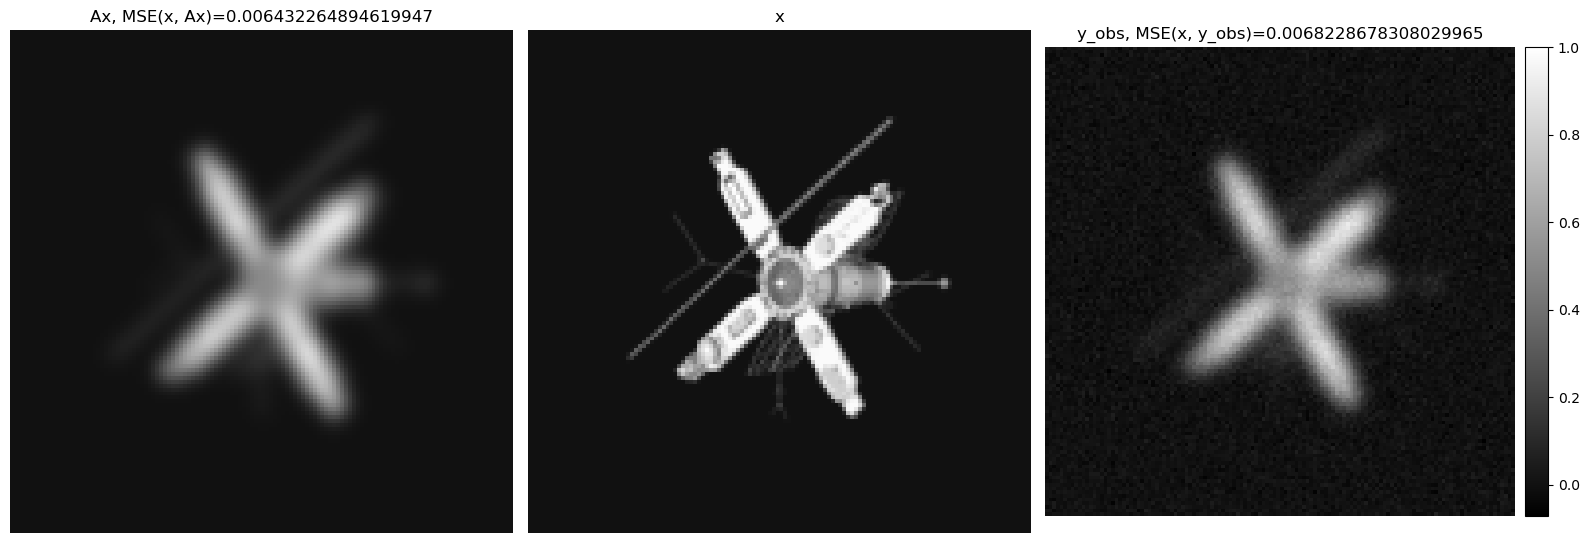

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 16))
# Find the global min and max values to normalize all images equally
vmin = min(info.exactData.min(), info.exactSolution.min(), y_obs.min())
vmax = max(info.exactData.max(), info.exactSolution.max(), y_obs.max())
# Plot each image
im1 = axes[0].imshow(np.reshape(info.exactData, (128, 128)), cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Ax, MSE(x, Ax)={}".format(mse(info.exactData, info.exactSolution)))
axes[0].axis("off")
im2 = axes[1].imshow(np.reshape(info.exactSolution, (128, 128)), cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("x")
axes[1].axis("off")
im3 = axes[2].imshow(np.reshape(y_obs, (128, 128)), cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title("y_obs, MSE(x, y_obs)={}".format(mse(y_obs, info.exactSolution)))
axes[2].axis("off")
# Create an axis for the colorbar and adjust the layout
divider = make_axes_locatable(axes[2])
cax = divider.append_axes("right", size="5%", pad=0.1)
# Add the colorbar
cbar = fig.colorbar(im3, cax=cax)

# Adjust layout to ensure titles and labels fit well
plt.tight_layout()

In [24]:
y=Gaussian(mean=A, cov=sigma2)
likelihood=y(y=y_obs)

cuda:0


Text(0.5, 1.0, 'Denoiser with s=$\\sigma$ (MSE=0.003978300565695557)')

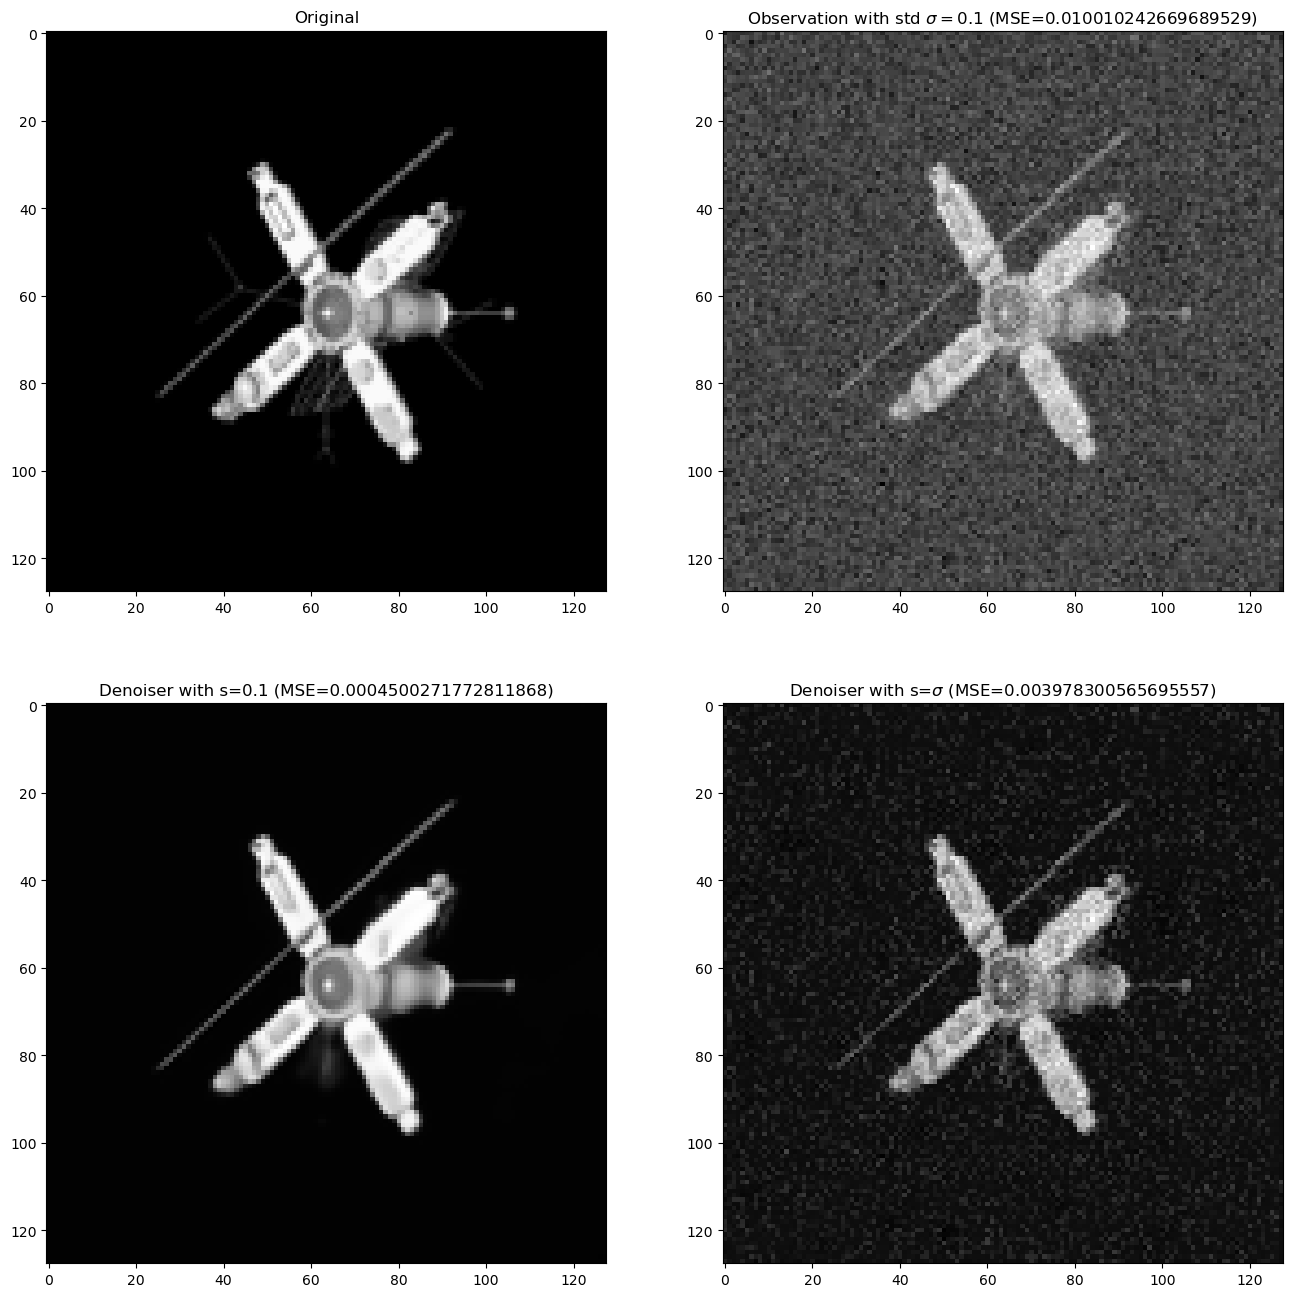

In [25]:
denoiser_name="drunet"

N=int(np.sqrt(info.exactSolution.shape[0]))

if denoiser_name=="drunet":
    from deepinv.models import DRUNet
    device="cuda:0" if torch.cuda.is_available() else "cpu" # "cpu" or "cuda:0"
    print(device)
    dinv_denoiser=DRUNet(in_channels=1,out_channels=1,pretrained="download",device=device)
    def denoiser(x, restoration_strength=None):
        xt=torch.tensor(np.reshape(x,(N,N)), device=device, dtype=torch.float32)
        xt=xt.unsqueeze(0).unsqueeze(0)
        xrt=dinv_denoiser(xt,np.sqrt(restoration_strength))
        xrt=torch.squeeze(xrt)
        xr=xrt.cpu().detach().numpy()
        return xr.flatten(), None


s=0.1
xt=torch.tensor(np.reshape(info.exactSolution, (N,N)), device=device, dtype=torch.float32)
xt=xt.unsqueeze(0).unsqueeze(0)
yt=xt+s*torch.randn(xt.shape, device=device)

xrt=dinv_denoiser(yt, s)
xr=torch.squeeze(xrt)
xr=xr.cpu().detach().numpy()

xr2t=dinv_denoiser(yt, sigma)
xr2=torch.squeeze(xr2t)
xr2=xr2.cpu().detach().numpy()
y=torch.squeeze(yt)
y=y.cpu().numpy()
fig=plt.figure(figsize=(16,16))
ax1=fig.add_subplot(2,2,1)
ax1.imshow(np.reshape(info.exactSolution, (N, N)), cmap="gray")
ax1.set_title("Original")
ax2=fig.add_subplot(2,2,2)
ax2.imshow(y, cmap="gray")
ax2.set_title(r"Observation with std $\sigma={}$ (MSE={})".format(s, mse(np.reshape(info.exactSolution, (N, N)), y)))
ax3=fig.add_subplot(2,2,3)
ax3.imshow(xr, cmap="gray")
ax3.set_title("Denoiser with s={} (MSE={})".format(s, mse(np.reshape(info.exactSolution, (N, N)), xr)))
ax4=fig.add_subplot(2,2,4)
ax4.imshow(xr2, cmap="gray")
ax4.set_title(r"Denoiser with s=$\sigma$ (MSE={})".format(mse(np.reshape(info.exactSolution, (N, N)), xr2)))

In [26]:
restorator=RestorationPrior(
    denoiser,
    geometry=likelihood.model.domain_geometry
)

In [27]:
posterior=Posterior(likelihood, restorator)

In [28]:
Ns=25000
Nb=5000
Nt=10
scale = 0.000005
restoration_strength = sigma2

In [29]:
pnpula_sampler=PnPULA(target=posterior, scale=scale, smoothing_strength=restoration_strength) 

In [30]:
pnpula_sampler.sample(Ns=Ns)

Sample:   0%|          | 0/25000 [00:00<?, ?it/s]

Sample: 100%|██████████| 25000/25000 [16:23<00:00, 25.43it/s, acc rate: 100.00%]


 Sampler: 
	 PnPULA 
 Target: 
 	 Posterior(
    Equation:
	 p(restorator|y) ∝ L(restorator|y)p(restorator)
    Densities:
	y ~ CUQI Gaussian Likelihood function. Parameters ['x'].
 	restorator ~ CUQI RestorationPrior.
 ) 
 Current state: 
	 current_point: [-0.01642037 -0.01844685 -0.00642662 ...  0.01203916 -0.02592439
  0.00854399] 
	 current_target_grad: [ 42.40016925  47.96950601  17.20010142 ... -32.31174448  66.90646069
 -22.12890818] 
	 scale: 5e-06 

In [31]:
samples=pnpula_sampler.get_samples()
samples_warm=samples.burnthin(Nb=Nb, Nt=Nt)

(-0.5, 127.5, 127.5, -0.5)

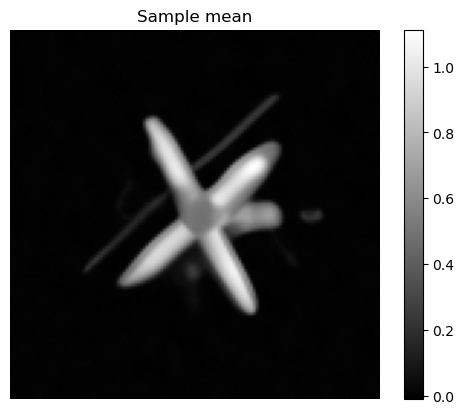

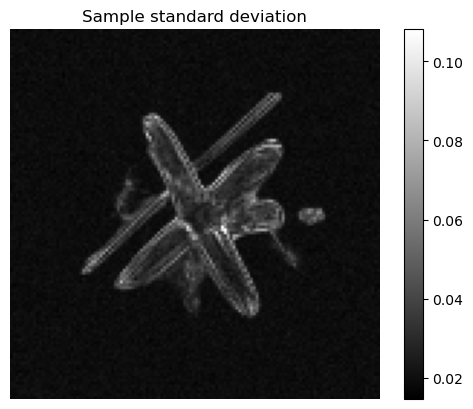

In [32]:
samples_warm.plot_mean()
plt.colorbar()
plt.axis('off')

plt.figure()
samples_warm.plot_std()
plt.colorbar()
plt.axis('off')

Selecting 5 randomly chosen variables


array([[<Axes: title={'center': 'x10811'}>,
        <Axes: title={'center': 'x15055'}>,
        <Axes: title={'center': 'x16257'}>],
       [<Axes: title={'center': 'x3691'}>,
        <Axes: title={'center': 'x4321'}>, <Axes: >]], dtype=object)

<Figure size 640x480 with 0 Axes>

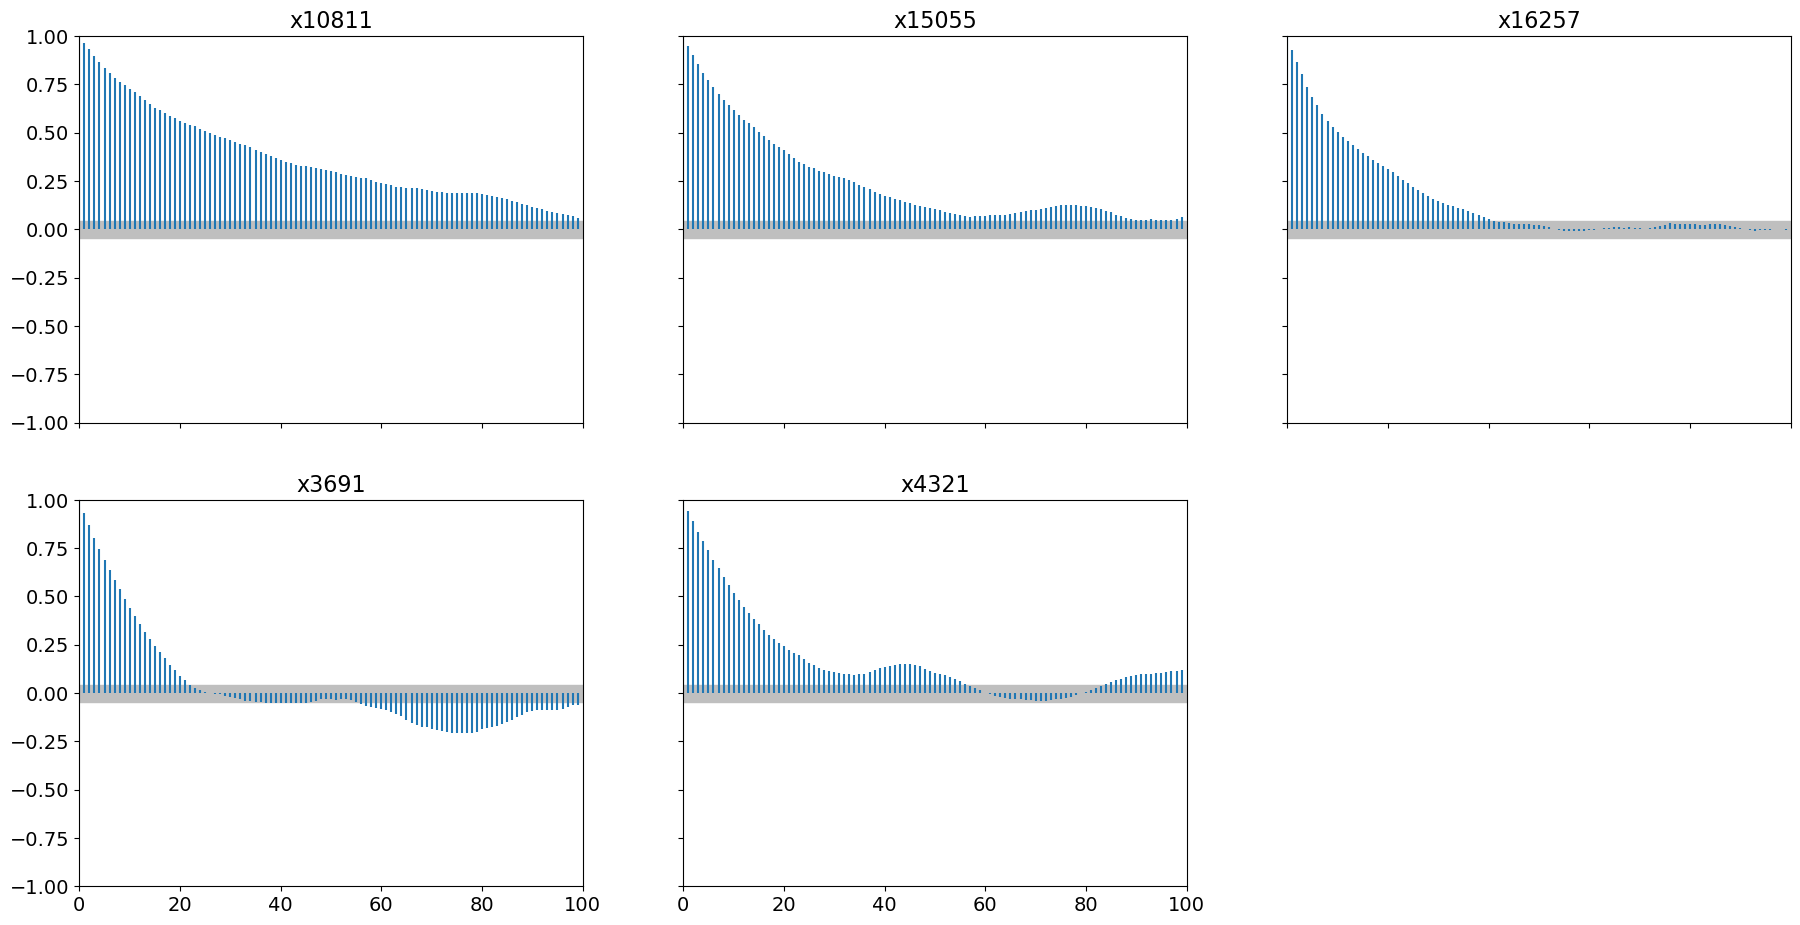

In [34]:
plt.figure()
samples_warm.plot_autocorrelation(max_lag=100)